# Análisis comparativo demográfico municipal

Compara indicadores del **municipio de interés** contra tres referencias:
- **Nacional** — totales del Censo 2020 para todo México
- **Estatal** — totales para el estado al que pertenece el municipio
- **Municipios vecinos** — cada municipio colindante identificado en el notebook 00

**Insumo:** tablas pre-procesadas en `datos/tablas/` generadas por `preparacion_datos.ipynb`.

**Flujo de trabajo:**
1. Ejecuta `preparacion_datos.ipynb` al menos una vez para generar las tablas.
2. Asegúrate de tener un archivo `vecinos_*.gpkg` en `datos/vecinos/`
   generado por el notebook 00 o las GUIs.
   Si no existe ninguno, usa los widgets de la sección 4.
3. Ejecuta las celdas de este notebook para generar tablas y gráficas.

In [1]:
import pandas as pd
import pyogrio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

## 1. Configuración

In [2]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
RUTA_TABLAS      = Path("../datos/tablas")
RUTA_VECINOS_DIR = Path("../datos/vecinos")
RUTA_SALIDA      = Path("../datos/comparativa")
RUTA_GRAFICOS    = RUTA_SALIDA / "graficos"

CVEGEO_MANUAL = None  # Sobreescribir con p.ej. "14039" para saltar auto-detección

# ── Estilo ────────────────────────────────────────────────────────────────────
COLOR_INTERES = "#c0392b"
COLOR_ESTADO  = "#2980b9"
COLOR_NAL     = "#27ae60"
COLOR_VECINO  = "#95a5a6"
FIG_DPI       = 150

## 2. Carga de tablas pre-procesadas

In [3]:
df_mun = pd.read_csv(RUTA_TABLAS / "municipal_2020.csv", dtype={"CVEGEO": str})
df_mun["CVEGEO"] = df_mun["CVEGEO"].str.zfill(5)

df_est = pd.read_csv(RUTA_TABLAS / "estatal_2020.csv", dtype={"CVEGEO": str})
df_est["CVEGEO"] = df_est["CVEGEO"].str.zfill(2)

df_nal = pd.read_csv(RUTA_TABLAS / "nacional_2020.csv", dtype={"CVEGEO": str})

df_desc = pd.read_csv(RUTA_TABLAS / "descriptores.csv")
DESCRIP = dict(zip(df_desc["CAMPO"].str.upper(), df_desc["DESCRIP"]))

print(f"Municipal : {len(df_mun):,} municipios · {df_mun.shape[1]} columnas")
print(f"Estatal   : {len(df_est):,} entidades  · {df_est.shape[1]} columnas")
print(f"Nacional  : {len(df_nal):,} registro   · {df_nal.shape[1]} columnas")

Municipal : 2,469 municipios · 399 columnas
Estatal   : 32 entidades  · 396 columnas
Nacional  : 1 registro   · 396 columnas


## 3. Selección del municipio de interés

El notebook detecta automáticamente el archivo `vecinos_*.gpkg` más reciente
generado por el notebook 00 o las GUIs.

Si no existe ninguno, usa la sección **4** para seleccionar el municipio manualmente.

In [4]:
if CVEGEO_MANUAL:
    CVEGEO_INTERES = str(CVEGEO_MANUAL).zfill(5)
    ruta_gpkg = RUTA_VECINOS_DIR / f"vecinos_{CVEGEO_INTERES}.gpkg"
    if not ruta_gpkg.exists():
        raise FileNotFoundError(f"No se encontró {ruta_gpkg}. Verifica CVEGEO_MANUAL.")
else:
    gpkg_files = sorted(
        RUTA_VECINOS_DIR.glob("vecinos_*.gpkg"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not gpkg_files:
        raise FileNotFoundError(
            f"No hay archivos vecinos_*.gpkg en {RUTA_VECINOS_DIR}.\n"
            "Ejecuta primero el notebook 00 o las GUIs, o usa la sección 4."
        )
    ruta_gpkg = gpkg_files[0]
    CVEGEO_INTERES = ruta_gpkg.stem.replace("vecinos_", "").zfill(5)

print(f"Archivo vecinos   : {ruta_gpkg}")
print(f"CVEGEO de interés : {CVEGEO_INTERES}")

Archivo vecinos   : ..\datos\vecinos\vecinos_09003.gpkg
CVEGEO de interés : 09003


In [5]:
# Soporta tanto GPKG de una sola capa "municipios" (con col. "rol")
# como GPKG de dos capas "municipio_interes" / "vecinos" / "colindantes"
layers = [l[0] for l in pyogrio.list_layers(str(ruta_gpkg))]

if "municipios" in layers:
    gdf_vec = pyogrio.read_dataframe(str(ruta_gpkg), layer="municipios")
    gdf_vec["CVEGEO"] = gdf_vec["CVEGEO"].astype(str).str.zfill(5)
    CVEGEO_INTERES = gdf_vec.loc[gdf_vec["rol"] == "municipio_interes", "CVEGEO"].values[0]
    vecinos_cvegeo = gdf_vec.loc[gdf_vec["rol"] != "municipio_interes", "CVEGEO"].tolist()
else:
    # Formato de dos capas (notebook 00 anterior)
    layer_vec = next(l for l in layers if l != "municipio_interes")
    gdf_mi  = pyogrio.read_dataframe(str(ruta_gpkg), layer="municipio_interes")
    gdf_v   = pyogrio.read_dataframe(str(ruta_gpkg), layer=layer_vec)
    gdf_mi["CVEGEO"] = gdf_mi["CVEGEO"].astype(str).str.zfill(5)
    gdf_v["CVEGEO"]  = gdf_v["CVEGEO"].astype(str).str.zfill(5)
    CVEGEO_INTERES = gdf_mi["CVEGEO"].values[0]
    vecinos_cvegeo = gdf_v["CVEGEO"].tolist()

CVE_ENT_INTERES = CVEGEO_INTERES[:2]
row_mi  = df_mun[df_mun["CVEGEO"] == CVEGEO_INTERES].iloc[0]
NOM_MUN = row_mi["NOMGEO"]
NOM_ENT = row_mi["NOM_ENT"]

print(f"Municipio de interés : {NOM_MUN}, {NOM_ENT}  (CVEGEO: {CVEGEO_INTERES})")
print(f"Municipios vecinos   : {len(vecinos_cvegeo)}")
for cve in vecinos_cvegeo:
    nom = df_mun.loc[df_mun["CVEGEO"] == cve, "NOMGEO"].values
    print(f"  {cve}  {nom[0] if len(nom) else '?'}")

Municipio de interés : Coyoacán, Ciudad de México  (CVEGEO: 09003)
Municipios vecinos   : 7
  09006  Iztacalco
  09007  Iztapalapa
  09008  La Magdalena Contreras
  09010  Álvaro Obregón
  09012  Tlalpan
  09013  Xochimilco
  09014  Benito Juárez


## 4. Grupos de indicadores

Ajusta los códigos si alguna etiqueta aparece como `[SIN DESCRIPCIÓN]`.

In [15]:
INDICATOR_GROUPS = {
    "A_estructura_basica": {
        "titulo": "Estructura básica de población",
        "variables": [
            "POB1",            # Población total
            "TCMA_2010_2020",  # Tasa de Crecimiento Media Anual 2010-2020 (%)
            "POB8_R",          # % 0-14 años
            "POB10_R",         # % 15-24 años
            "POB14_R",         # % 30-49 años
            "POB15_R",         # % 50-59 años
            "POB125_R",        # Relación hombres-mujeres
            "POB129_R",        # Edad mediana
        ],
    },
    "B_sexo": {
        "titulo": "Distribución por sexo",
        "variables": [
            "POB84_R",   # % Hombres
            "POB42_R",   # % Mujeres
            "POB125_R",  # Relación hombres-mujeres
        ],
    },
    "C_edad": {
        "titulo": "Estructura por edad",
        "variables": [
            "POB3_R","POB26_R","POB27_R","POB28_R","POB29_R","POB30_R","POB31_R",
            "POB32_R","POB33_R","POB34_R","POB35_R","POB36_R","POB37_R","POB38_R",
            "POB39_R","POB40_R","POB41_R",
            "POB126_R","POB127_R","POB128_R","POB132_R",
        ],
    },
    "D_migracion": {
        "titulo": "Migración",
        "variables": [
            "MIG1_R","MIG4_R","MIG7_R","MIG11_R","MIG14_R",
        ],
    },
    "E_etnicidad": {
        "titulo": "Etnicidad",
        "variables": [
            "INDI1_R","INDI4_R","INDI20_R","AFRO1_R",
        ],
    },
    "F_discapacidad": {
        "titulo": "Discapacidad",
        "variables": [
            "DISC1_R","DISC7_R","DISC8_R","DISC9_R",
            "DISC10_R","DISC11_R","DISC12_R","DISC13_R",
        ],
    },
}

print("Verificación de etiquetas:")
for gk, gcfg in INDICATOR_GROUPS.items():
    print(f"\n{'─'*54}")
    print(f"  {gk}: {gcfg['titulo']}")
    for campo in gcfg["variables"]:
        etiq = DESCRIP.get(campo, "[SIN DESCRIPCIÓN — verificar código]")
        print(f"    {campo:<18} {etiq}")

Verificación de etiquetas:

──────────────────────────────────────────────────────
  A_estructura_basica: Estructura básica de población
    POB1               Población total
    TCMA_2010_2020     Tasa de Crecimiento Media Anual 2010-2020 (%)
    POB8_R             Porcentaje de población de 0 a 14 años
    POB10_R            Porcentaje de población de 15 a 24 años
    POB14_R            Porcentaje de población de 30 a 49 años
    POB15_R            Porcentaje de población de 50 a 59 años
    POB125_R           Relación hombres-mujeres
    POB129_R           Edad mediana de la población total

──────────────────────────────────────────────────────
  B_sexo: Distribución por sexo
    POB84_R            Porcentaje de población masculina
    POB42_R            Porcentaje de población femenina
    POB125_R           Relación hombres-mujeres

──────────────────────────────────────────────────────
  C_edad: Estructura por edad
    POB3_R             Porcentaje de población de 0 a 4 años
  

## 6. Tablas comparativas

In [16]:
def _get(df, cvegeo_key, campo):
    r = df[df["CVEGEO"] == cvegeo_key]
    if r.empty or campo not in r.columns:
        return None
    val = r[campo].values[0]
    return None if pd.isna(val) else float(val)

def _nom_vecino(cve):
    nom = df_mun.loc[df_mun["CVEGEO"] == cve, "NOMGEO"].values
    return nom[0] if len(nom) else cve

def construir_tabla(gcfg):
    cvegeo_nal = df_nal["CVEGEO"].values[0]
    filas = []
    for campo in gcfg["variables"]:
        fila = {
            "Indicador": DESCRIP.get(campo, campo),
            "Campo":     campo,
            NOM_MUN:     _get(df_mun, CVEGEO_INTERES, campo),
            NOM_ENT:     _get(df_est, CVE_ENT_INTERES, campo),
            "Nacional":  _get(df_nal, cvegeo_nal, campo),
        }
        for cve in vecinos_cvegeo:
            fila[_nom_vecino(cve)] = _get(df_mun, cve, campo)
        filas.append(fila)
    return pd.DataFrame(filas)

tablas = {gk: construir_tabla(gcfg) for gk, gcfg in INDICATOR_GROUPS.items()}

for gk, df in tablas.items():
    print(f"\n{'═'*60}")
    print(f"  {INDICATOR_GROUPS[gk]['titulo']}")
    print(df.to_string(index=False))


════════════════════════════════════════════════════════════
  Estructura básica de población
                                    Indicador          Campo  Coyoacán  Ciudad de México    Nacional  Iztacalco  Iztapalapa  La Magdalena Contreras  Álvaro Obregón  Tlalpan  Xochimilco  Benito Juárez
                              Población total           POB1  614447.0         9209944.0 126014024.0   404695.0   1835486.0                247622.0        759137.0 699928.0    442178.0       434153.0
Tasa de Crecimiento Media Anual 2010-2020 (%) TCMA_2010_2020       NaN               NaN         NaN        NaN         NaN                     NaN             NaN      NaN         NaN            NaN
       Porcentaje de población de 0 a 14 años         POB8_R      14.9              18.0        25.3       17.1        20.0                    19.1            17.9     18.5        20.1           11.8
      Porcentaje de población de 15 a 24 años        POB10_R      14.1              14.8        16.9     

## 7. Visualización

Generando gráficas...

Estructura básica de población


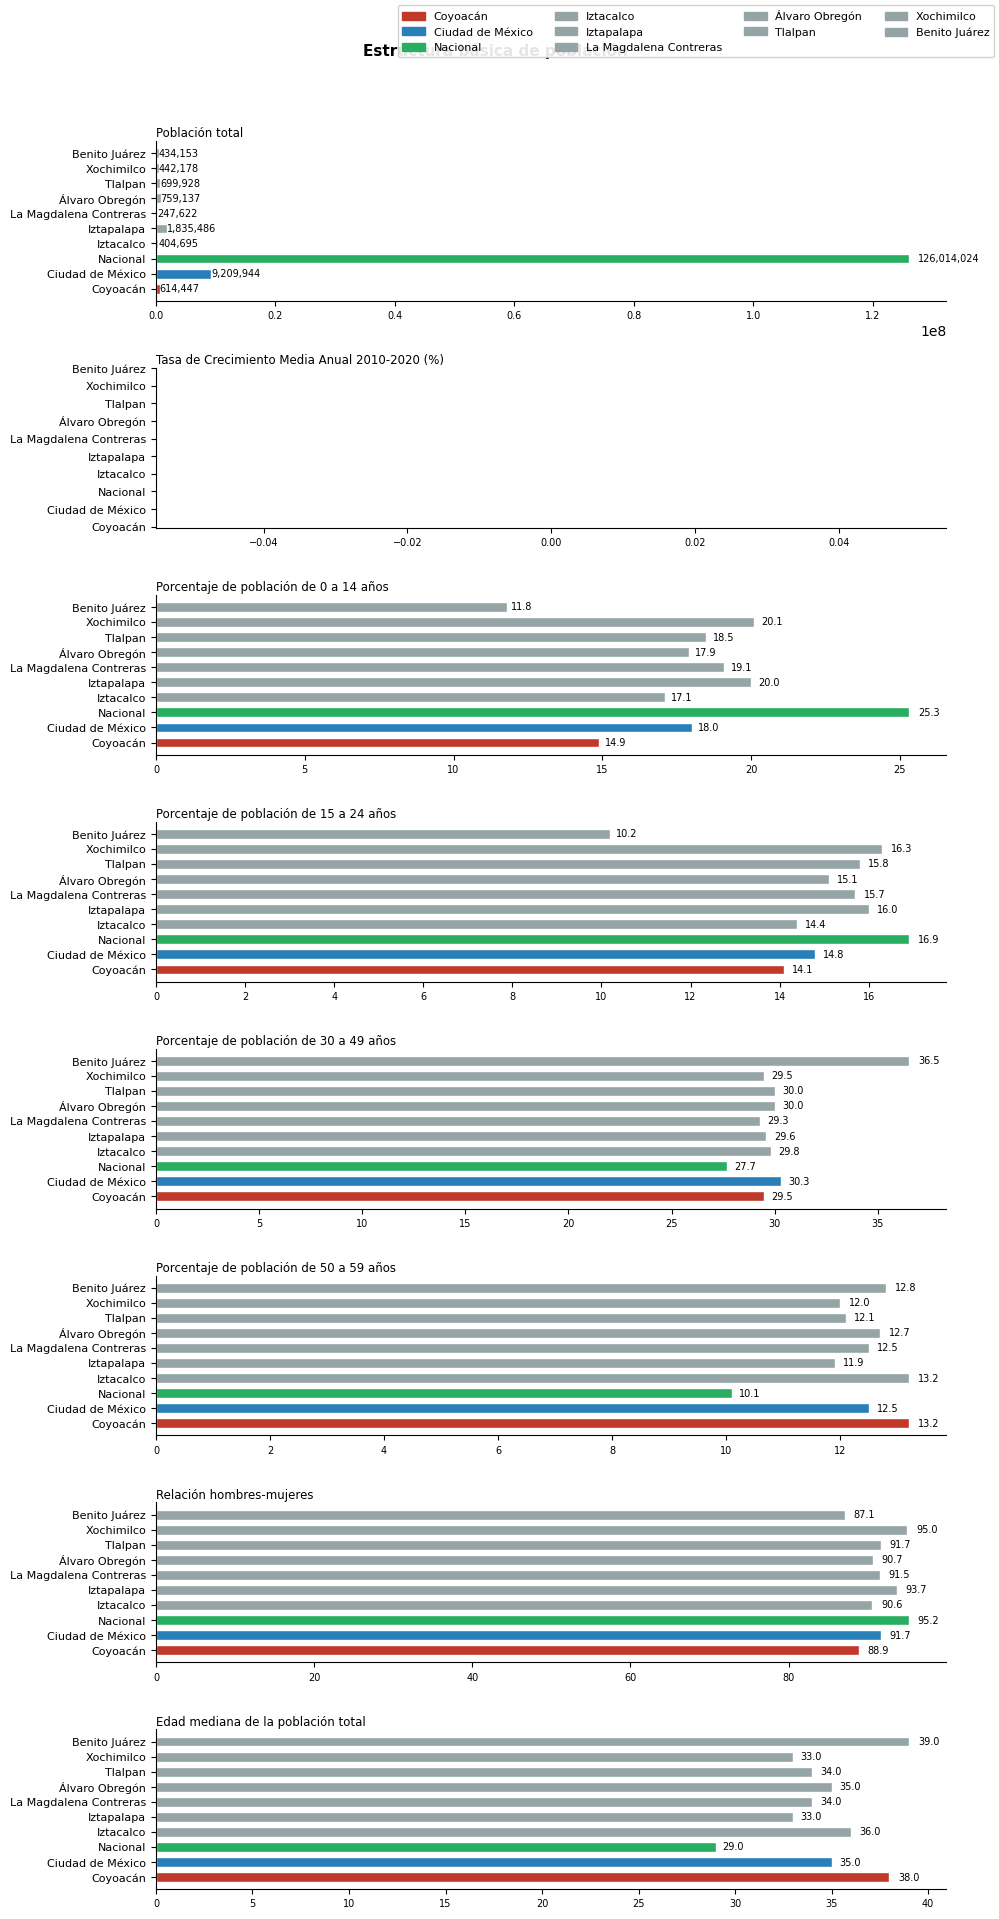

  Guardado: ..\datos\comparativa\graficos\graf_A_estructura_basica_09003.png

Distribución por sexo


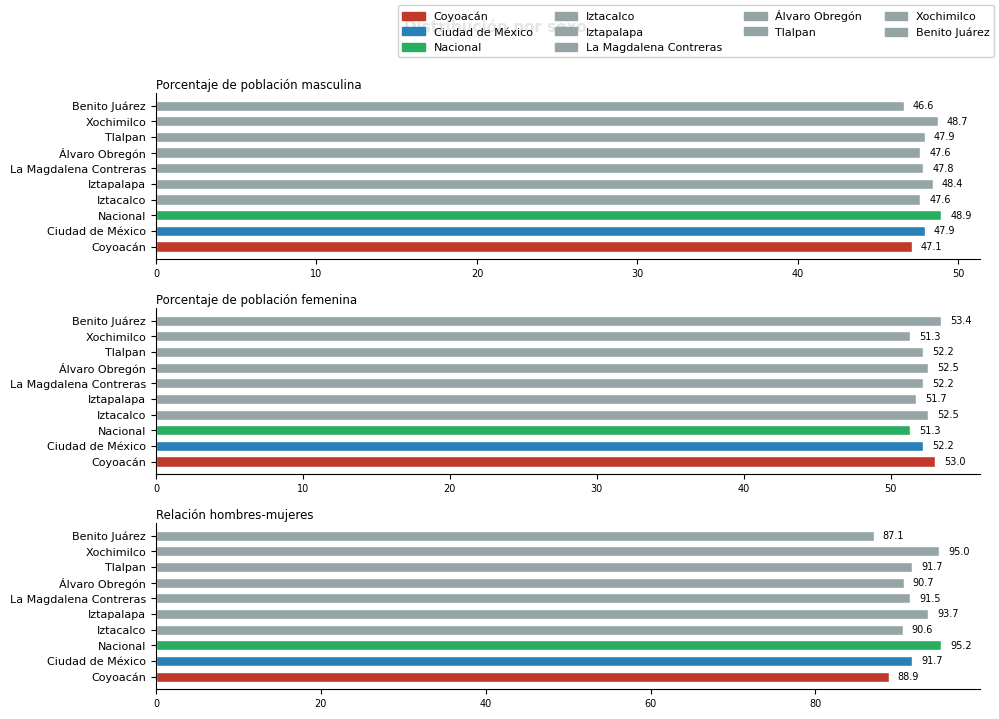

  Guardado: ..\datos\comparativa\graficos\graf_B_sexo_09003.png

Estructura por edad


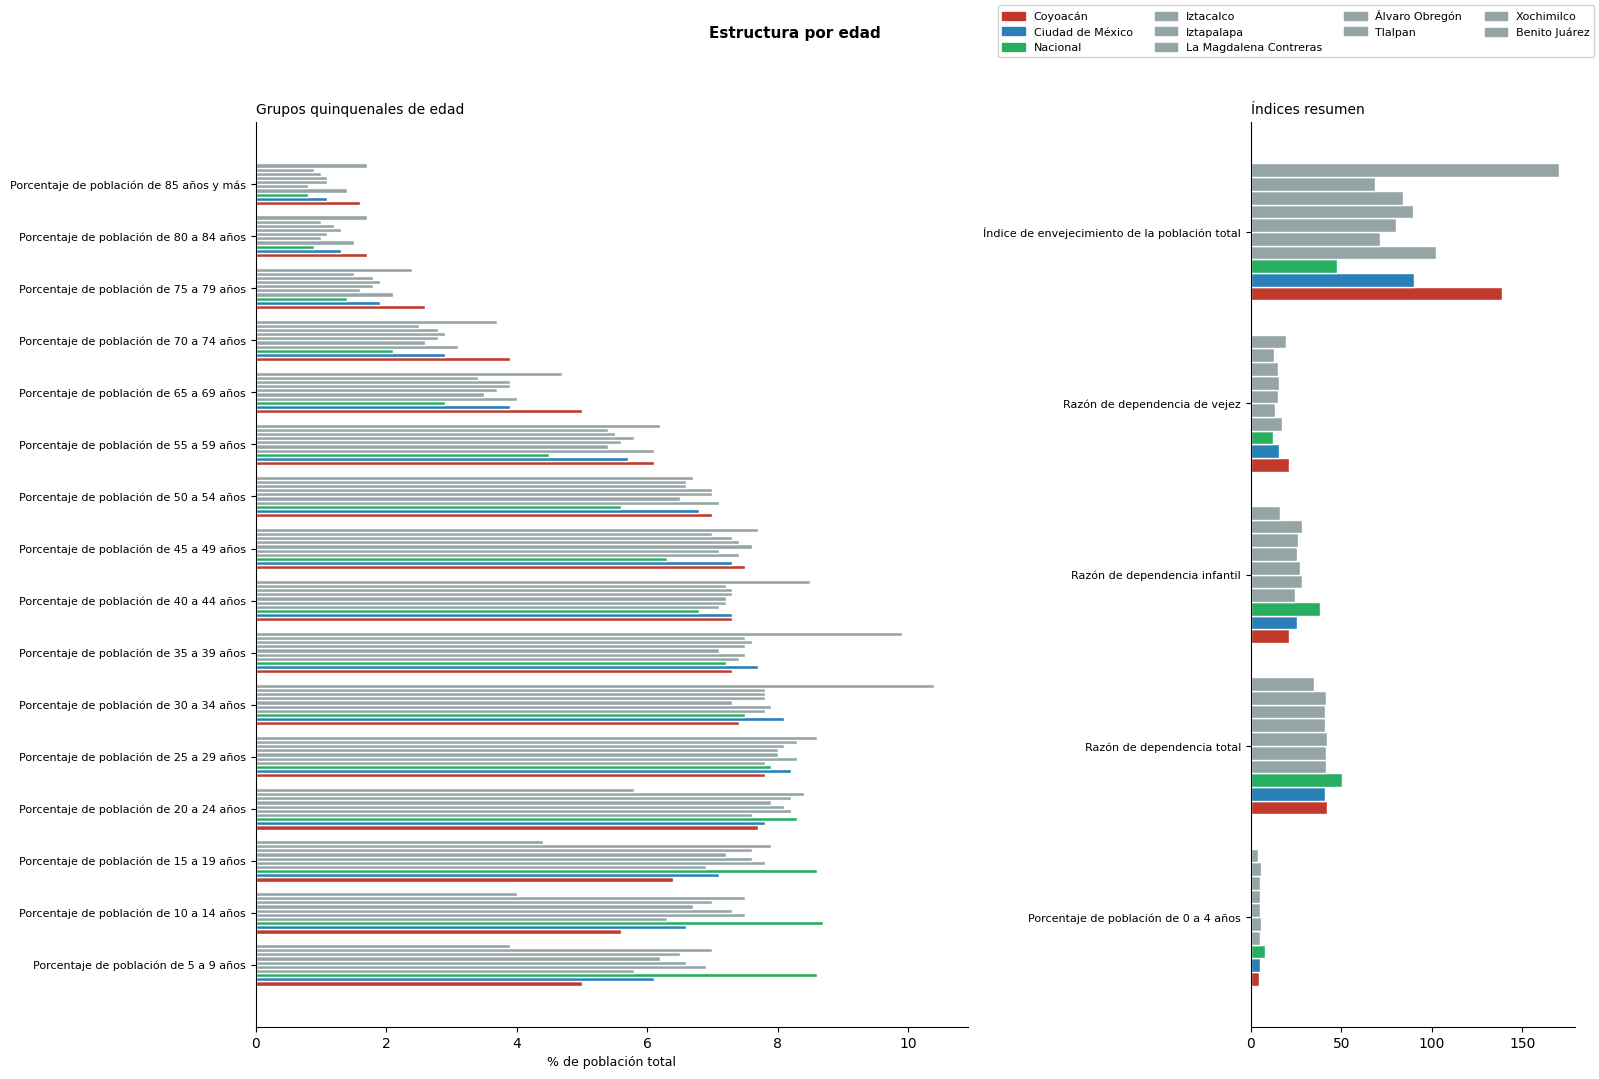

  Guardado: ..\datos\comparativa\graficos\graf_C_edad_09003.png

Migración


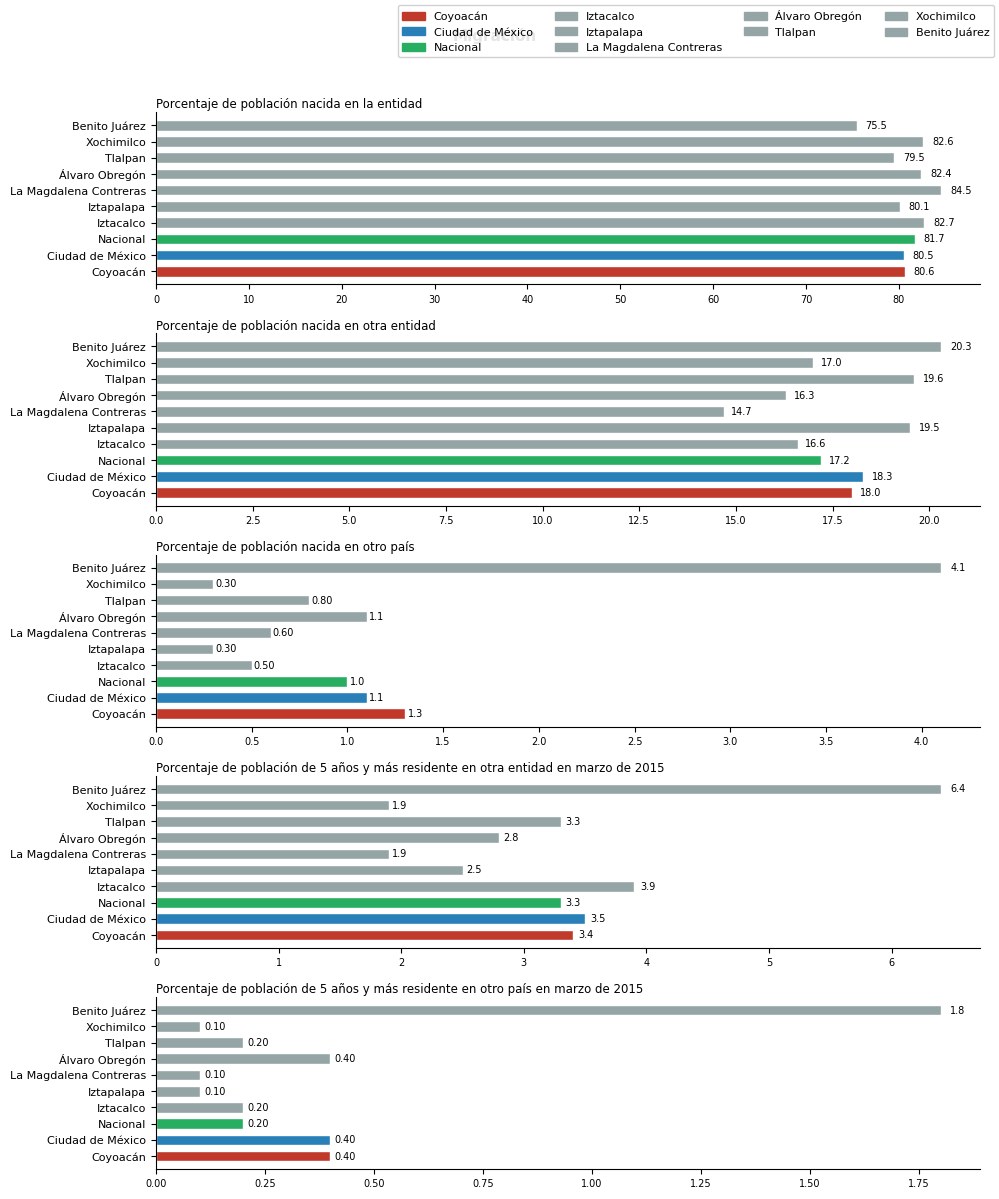

  Guardado: ..\datos\comparativa\graficos\graf_D_migracion_09003.png

Etnicidad


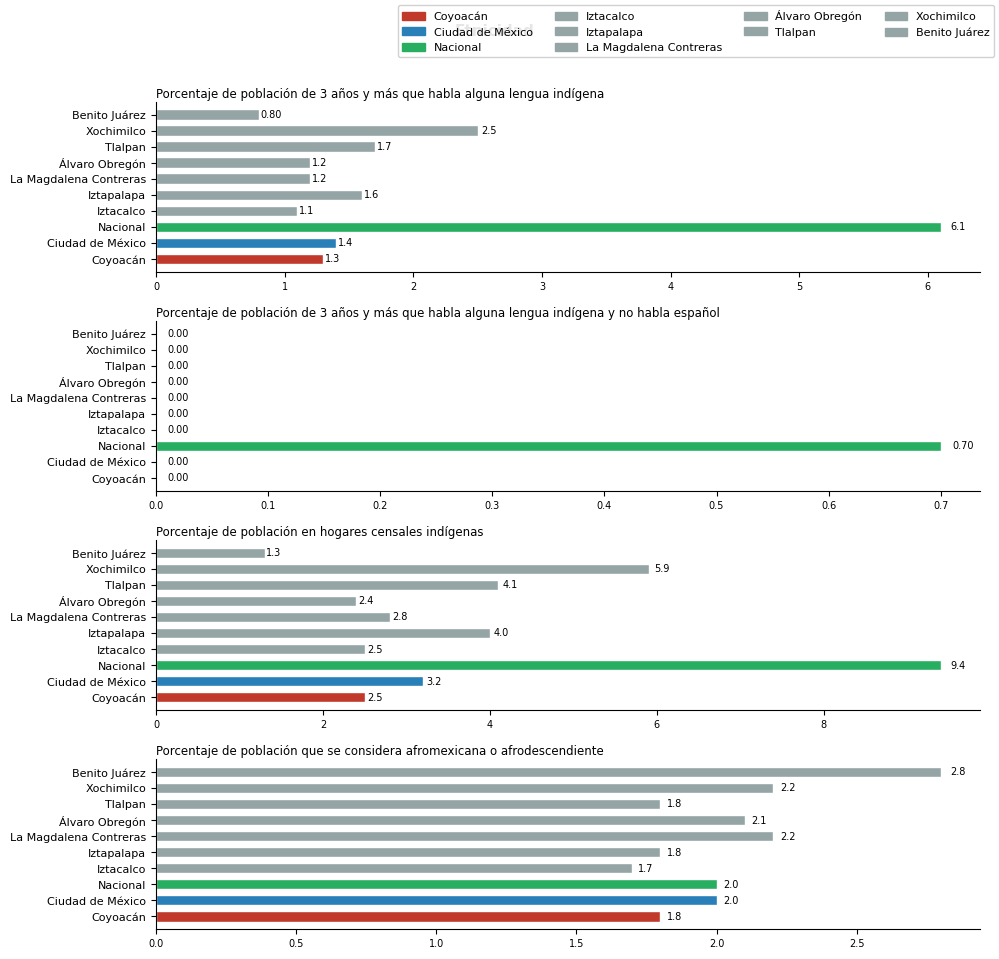

  Guardado: ..\datos\comparativa\graficos\graf_E_etnicidad_09003.png

Discapacidad


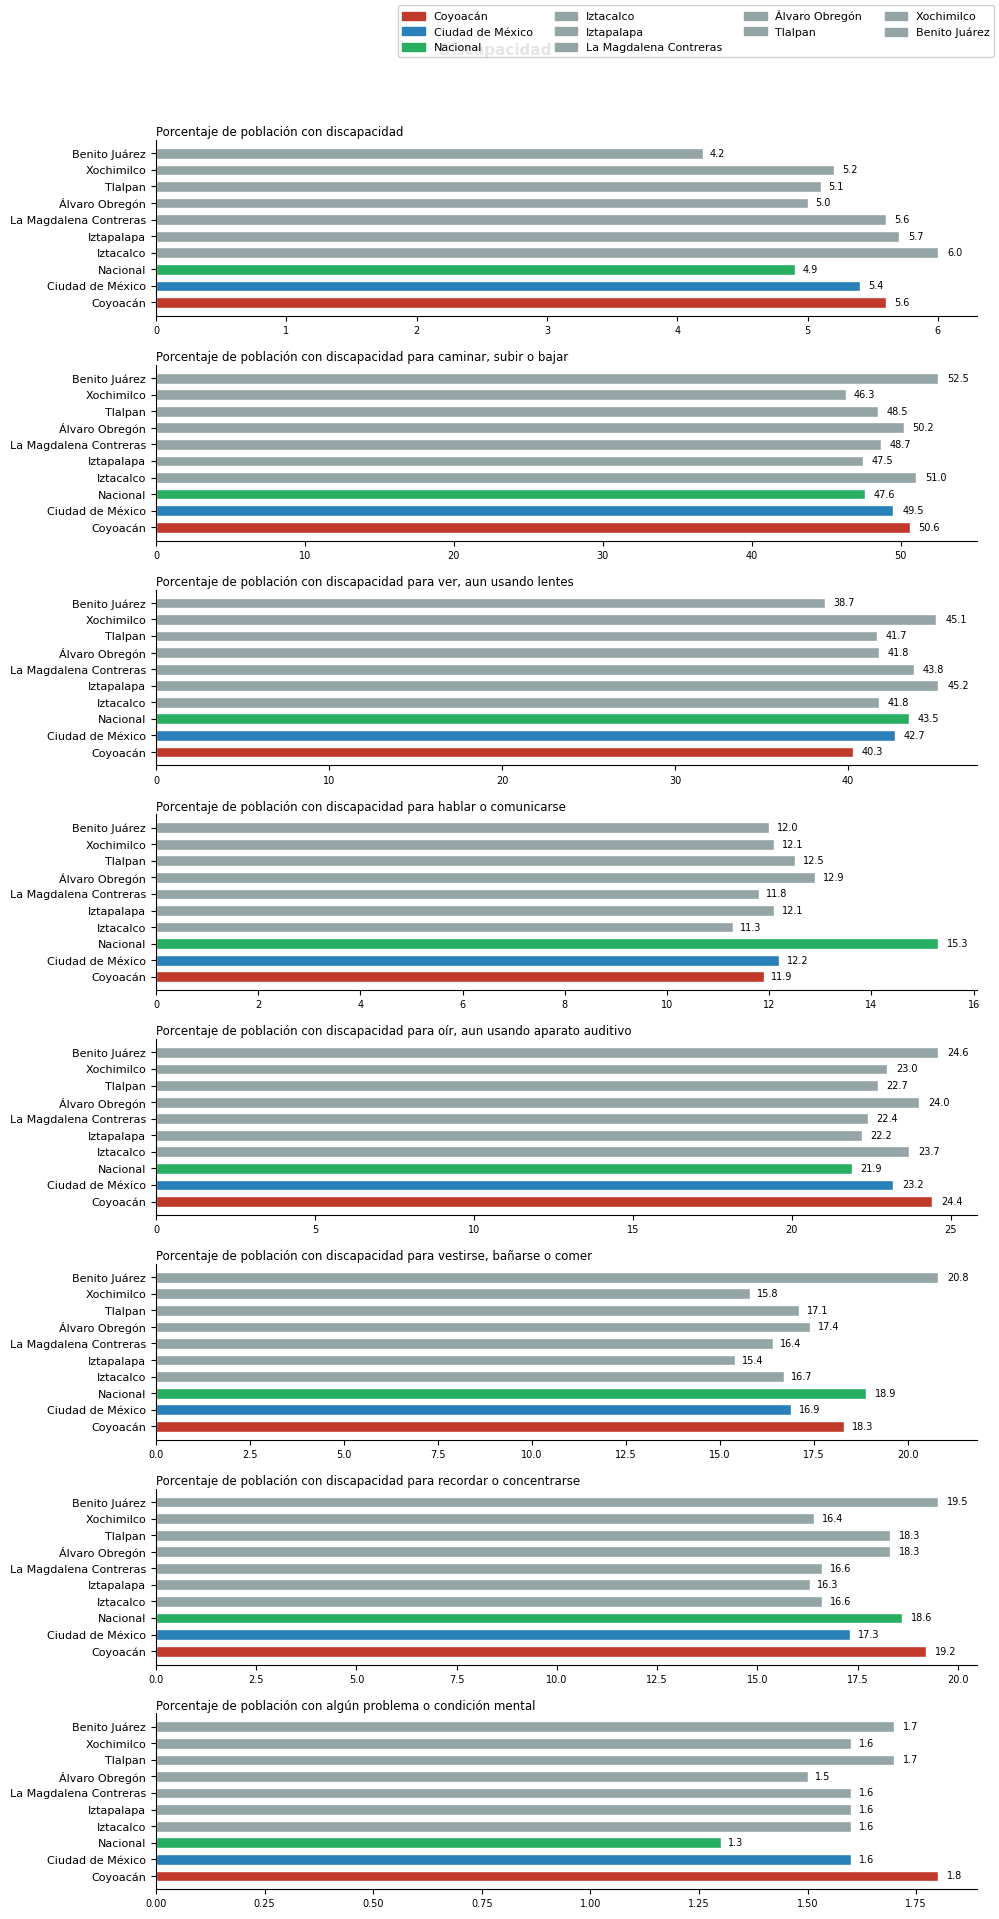

  Guardado: ..\datos\comparativa\graficos\graf_F_discapacidad_09003.png

Listo.


In [17]:
RUTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

def _color_col(col_name):
    if col_name == NOM_MUN:    return COLOR_INTERES
    if col_name == NOM_ENT:    return COLOR_ESTADO
    if col_name == "Nacional": return COLOR_NAL
    return COLOR_VECINO

def _leyenda(fig, col_comp):
    handles = [mpatches.Patch(color=_color_col(c), label=c) for c in col_comp]
    fig.legend(handles=handles, loc="upper right", fontsize=8,
               framealpha=0.9, ncol=min(len(handles), 4))

def _guardar(fig, gk):
    ruta = RUTA_GRAFICOS / f"graf_{gk}_{CVEGEO_INTERES}.png"
    fig.savefig(ruta, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"  Guardado: {ruta}")

def _barras_simples(ax, row, col_comp):
    vals_etqs = [(c, row.get(c)) for c in col_comp if row.get(c) is not None]
    if not vals_etqs:
        ax.set_visible(False)
        return
    etqs, vs = zip(*vals_etqs)
    cols = [_color_col(e) for e in etqs]
    bars = ax.barh(range(len(vs)), vs, color=cols, edgecolor="white", height=0.65)
    ax.set_yticks(range(len(vs)))
    ax.set_yticklabels(etqs, fontsize=8)
    ax.set_title(row["Indicador"], fontsize=8.5, loc="left", pad=3)
    ax.tick_params(axis="x", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, v in zip(bars, vs):
        fmt = f"{v:,.0f}" if abs(v) >= 100 else f"{v:.2f}" if abs(v) < 1 else f"{v:.1f}"
        ax.text(
            bar.get_width() + max(abs(v) * 0.012, 0.01),
            bar.get_y() + bar.get_height() / 2,
            fmt, va="center", fontsize=7,
        )

def graficar_estandar(gk, gcfg, df_tabla):
    col_excluir = {"Indicador", "Campo"}
    col_comp = [c for c in df_tabla.columns if c not in col_excluir]
    n = len(df_tabla)
    fig, axes = plt.subplots(n, 1, figsize=(10, max(2.4 * n, 3)))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df_tabla.iterrows()):
        _barras_simples(ax, row, col_comp)
    _leyenda(fig, col_comp)
    fig.suptitle(gcfg["titulo"], fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    _guardar(fig, gk)

def graficar_edad(gcfg, df_tabla):
    col_excluir = {"Indicador", "Campo"}
    col_comp = [c for c in df_tabla.columns if c not in col_excluir]
    n_comp = len(col_comp)
    CODIGOS_Q = {
        "POB2_R","POB26_R","POB27_R","POB28_R","POB29_R","POB30_R","POB31_R",
        "POB32_R","POB33_R","POB34_R","POB35_R","POB36_R","POB37_R","POB38_R",
        "POB39_R","POB40_R","POB41_R",
    }
    df_q   = df_tabla[df_tabla["Campo"].isin(CODIGOS_Q)].reset_index(drop=True)
    df_idx = df_tabla[~df_tabla["Campo"].isin(CODIGOS_Q)].reset_index(drop=True)
    bar_h = min(0.8 / n_comp, 0.35)
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(16, max(len(df_q) * 0.55 + 2, 8)),
        gridspec_kw={"width_ratios": [2.2, 1]},
    )
    for i, col in enumerate(col_comp):
        offset = (i - n_comp / 2 + 0.5) * bar_h
        ys = [j + offset for j in range(len(df_q))]
        vs = [df_q.iloc[j].get(col) for j in range(len(df_q))]
        ax1.barh(ys, vs, height=bar_h, color=_color_col(col), edgecolor="white", label=col)
    ax1.set_yticks(range(len(df_q)))
    ax1.set_yticklabels(df_q["Indicador"].tolist(), fontsize=8)
    ax1.set_xlabel("% de población total", fontsize=9)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.set_title("Grupos quinquenales de edad", fontsize=10, loc="left")
    for i, col in enumerate(col_comp):
        offset = (i - n_comp / 2 + 0.5) * bar_h
        ys = [j + offset for j in range(len(df_idx))]
        vs = [df_idx.iloc[j].get(col) for j in range(len(df_idx))]
        ax2.barh(ys, vs, height=bar_h, color=_color_col(col), edgecolor="white")
    ax2.set_yticks(range(len(df_idx)))
    ax2.set_yticklabels(df_idx["Indicador"].tolist(), fontsize=8)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_title("Índices resumen", fontsize=10, loc="left")
    _leyenda(fig, col_comp)
    fig.suptitle(gcfg["titulo"], fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    _guardar(fig, "C_edad")

print("Generando gráficas...")
for gk, gcfg in INDICATOR_GROUPS.items():
    print(f"\n{gcfg['titulo']}")
    if gk == "C_edad":
        graficar_edad(gcfg, tablas[gk])
    else:
        graficar_estandar(gk, gcfg, tablas[gk])
print("\nListo.")

## 8. Exportación

Tablas comparativas exportadas a Excel (una hoja por grupo de indicadores).

In [18]:
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)
ruta_xlsx = RUTA_SALIDA / f"comparativa_{CVEGEO_INTERES}.xlsx"

try:
    with pd.ExcelWriter(ruta_xlsx, engine="openpyxl") as writer:
        for gk, df in tablas.items():
            df.to_excel(writer, sheet_name=gk[:31], index=False)
    print(f"Excel guardado: {ruta_xlsx}")
except ImportError:
    for gk, df in tablas.items():
        ruta_csv = RUTA_SALIDA / f"comparativa_{CVEGEO_INTERES}_{gk}.csv"
        df.to_csv(ruta_csv, index=False, encoding="utf-8-sig")
        print(f"CSV guardado : {ruta_csv}")
    print("\nNOTA: instala openpyxl para exportar a Excel en lugar de CSV.")

Excel guardado: ..\datos\comparativa\comparativa_09003.xlsx
